<a href="https://colab.research.google.com/github/layan3254/Deep_learning/blob/main/Amazon_Review_torch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import kagglehub
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler

In [ ]:
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
df = pd.read_csv(os.path.join(path, "Reviews.csv")).dropna()
df = df[["UserId", "ProductId", "Score", "Summary", "Text"]].dropna()
df = df.sample(1000, random_state=42).reset_index(drop=True)

In [ ]:
df.head()

,UserId,ProductId,Score,Summary,Text
0,A2R2GG6WW0J56R,B001PO7FIU,5,Avocado Oil,"Avocado oil beats olive oil for dressings, any..."
1,A3SJSHRFGEV49,B001M08YZA,4,"Healthy, tastes-oky","New years resolution season and all, bought pr..."
2,AIDPKNFYTTJ9Y,B002O19HWU,1,Peaches from China :-(,I was pretty sad when I got these peaches (whi...
3,A3LWC21A3VEVS3,B000CQG8KS,5,Perhaps Brewing Wrong?,I find that most (not all) people in North Ame...
4,A2A8ANYRNWSKP1,B001IZGC58,5,Works Great!,"Love that this is recycled, works just as well..."


In [ ]:
# Label Encoding للهويات
user_enc = LabelEncoder()
item_enc = LabelEncoder()
df['user_idx'] = user_enc.fit_transform(df['UserId'])
df['item_idx'] = item_enc.fit_transform(df['ProductId'])

In [ ]:
df["label"] = (df["Score"] >= 4).astype(int)

df["review_text"] = df["Summary"] + " " + df["Text"]

In [ ]:
tfidf = TfidfVectorizer(max_features=500, stop_words="english")
X_text = tfidf.fit_transform(df["review_text"]).toarray()

In [ ]:
user_feat = df["user_idx"].values.reshape(-1, 1)
item_feat = df["item_idx"].values.reshape(-1, 1)
X_combined = np.hstack((user_feat, item_feat, X_text))
y = df["label"].values

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
baseline_model = LogisticRegression()
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_preds)

In [ ]:

print(classification_report(y_test, baseline_preds))

              precision    recall  f1-score   support

           0       0.44      0.48      0.46        46
           1       0.84      0.82      0.83       154

    accuracy                           0.74       200
   macro avg       0.64      0.65      0.64       200
weighted avg       0.75      0.74      0.74       200



In [ ]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)

In [ ]:
class RecModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

model = RecModel(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# training
epochs = 50
train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")


Epoch 1/50 - Loss: 0.7286
Epoch 2/50 - Loss: 0.6995
Epoch 3/50 - Loss: 0.6712
Epoch 4/50 - Loss: 0.6455
Epoch 5/50 - Loss: 0.6228
Epoch 6/50 - Loss: 0.5984
Epoch 7/50 - Loss: 0.5755
Epoch 8/50 - Loss: 0.5549
Epoch 9/50 - Loss: 0.5304
Epoch 10/50 - Loss: 0.5106
Epoch 11/50 - Loss: 0.4885
Epoch 12/50 - Loss: 0.4683
Epoch 13/50 - Loss: 0.4476
Epoch 14/50 - Loss: 0.4290
Epoch 15/50 - Loss: 0.4092
Epoch 16/50 - Loss: 0.3913
Epoch 17/50 - Loss: 0.3713
Epoch 18/50 - Loss: 0.3552
Epoch 19/50 - Loss: 0.3359
Epoch 20/50 - Loss: 0.3184
Epoch 21/50 - Loss: 0.3020
Epoch 22/50 - Loss: 0.2848
Epoch 23/50 - Loss: 0.2700
Epoch 24/50 - Loss: 0.2541
Epoch 25/50 - Loss: 0.2409
Epoch 26/50 - Loss: 0.2269
Epoch 27/50 - Loss: 0.2130
Epoch 28/50 - Loss: 0.2006
Epoch 29/50 - Loss: 0.1894
Epoch 30/50 - Loss: 0.1763
Epoch 31/50 - Loss: 0.1666
Epoch 32/50 - Loss: 0.1556
Epoch 33/50 - Loss: 0.1450
Epoch 34/50 - Loss: 0.1356
Epoch 35/50 - Loss: 0.1260
Epoch 36/50 - Loss: 0.1172
Epoch 37/50 - Loss: 0.1090
Epoch 38/5

In [ ]:
model.eval()
with torch.no_grad():
    raw_preds = model(X_test_t)
    deep_preds = (raw_preds > 0.5).int().numpy()
    deep_acc = accuracy_score(y_test, deep_preds)

In [ ]:
#
print("\n" + "="*30)
print("RESULTS COMPARISON")
print("="*30)
print(f"Baseline (Logistic Regression) Accuracy: {baseline_acc:.4f}")
print(f"Deep Learning Accuracy: {deep_acc:.4f}")
print("\nDetailed Report for Deep Learning:")
print(classification_report(y_test, deep_preds))


RESULTS COMPARISON
Baseline (Logistic Regression) Accuracy: 0.7400
Deep Learning Accuracy: 0.8150

Detailed Report for Deep Learning:
              precision    recall  f1-score   support

           0       0.60      0.57      0.58        46
           1       0.87      0.89      0.88       154

    accuracy                           0.81       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.81      0.81      0.81       200



In [ ]:
# Comparison:
print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Deep Learning Accuracy: {deep_acc:.4f}")

Baseline Accuracy: 0.7400
Deep Learning Accuracy: 0.8150


Text(0.5, 0, 'Epochs')

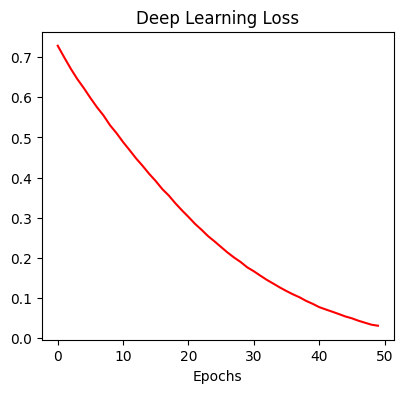

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, color='red')
plt.title("Deep Learning Loss")
plt.xlabel("Epochs")

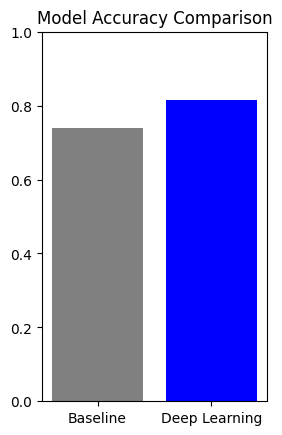

In [ ]:
plt.subplot(1, 2, 2)
plt.bar(["Baseline", "Deep Learning"], [baseline_acc, deep_acc], color=['gray', 'blue'])
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1.0)
plt.show()